In [17]:
# ============================================
# IMPORT REQUIRED LIBRARIES
# ============================================

import os

import cv2

import numpy as np

import matplotlib.pyplot as plt

from PIL import Image

import torch

import timm

import random

from torchvision import transforms

from pytorch_grad_cam import GradCAM

from pytorch_grad_cam.utils.image import (

    show_cam_on_image
)

In [18]:
# ============================================
# DEVICE CONFIGURATION
# ============================================

device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"
)

print("Using Device:", device)

Using Device: cuda


In [19]:
# # ============================================
# # LOAD TRAINED EFFICIENTNET MODEL
# # ============================================

# model = timm.create_model(

#     "efficientnet_b0",

#     pretrained=False,

#     num_classes=5
# )

# model.load_state_dict(

#     torch.load(

#         "../models/efficientnet/best_efficientnet_b0.pth",

#         map_location=device
#     )
# )

# model = model.to(device)

# model.eval()

# print("Trained EfficientNet Loaded!")

# ============================================
# LOAD TRAINED EFFICIENTNET B2 MODEL
# ============================================

# ============================================
# LOAD TRAINED EFFICIENTNET B2 MODEL
# ============================================

from torchvision import models
import torch.nn as nn

# ============================================
# CREATE MODEL
# ============================================

model = models.efficientnet_b2(weights=None)

# ============================================
# REPLACE CLASSIFIER
# ============================================

num_features = model.classifier[1].in_features

model.classifier = nn.Sequential(

    nn.Dropout(0.4),

    nn.Linear(num_features, 5)
)

# ============================================
# LOAD TRAINED WEIGHTS
# ============================================

model.load_state_dict(

    torch.load(

        "../models/efficientnet/best_efficientnet_b2.pth",

        map_location=device
    )
)

# ============================================
# MOVE MODEL TO DEVICE
# ============================================

model = model.to(device)

model.eval()

print("Trained EfficientNetB2 Loaded Successfully!")

Trained EfficientNetB2 Loaded Successfully!


In [20]:
# # ============================================
# # SELECT TEST IMAGE
# # ============================================

# image_dir = "../dataset/enhanced_test/2"

# image_name = os.listdir(image_dir)[0]

# image_path = os.path.join(

#     image_dir,

#     image_name
# )

# print("Selected Image:", image_path)

# ============================================
# SELECT TEST IMAGE
# ============================================


# Path to test dataset
test_dir = "../dataset/test"

# Random DR class
selected_class = random.choice([
    "0",
    "1",
    "2",
    "3",
    "4"
])

# Random image from selected class
image_name = random.choice(
    os.listdir(
        os.path.join(test_dir, selected_class)
    )
)

# Full image path
test_image_path = os.path.join(
    test_dir,
    selected_class,
    image_name
)

print(f"Selected Class: {selected_class}")
print(f"Selected Image: {image_name}")

print("\nImage Path:")
print(test_image_path)

Selected Class: 2
Selected Image: 9904939ab83d.png

Image Path:
../dataset/test\2\9904939ab83d.png


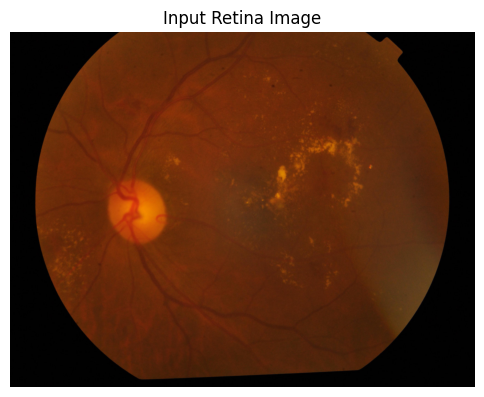

Image Loaded Successfully!


In [21]:
# # ============================================
# # LOAD RETINA IMAGE
# # ============================================

# image = Image.open(
#     image_path
# ).convert("RGB")

# plt.figure(figsize=(6, 6))

# plt.imshow(image)

# plt.title("Original Retina Image")

# plt.axis("off")

# plt.show()

# ============================================
# LOAD RETINA IMAGE
# ============================================

from PIL import Image
import matplotlib.pyplot as plt

# Load image
image_path = test_image_path

original_image = Image.open(image_path).convert("RGB")

# Display image
plt.figure(figsize=(6,6))

plt.imshow(original_image)

plt.title("Input Retina Image")

plt.axis("off")

plt.show()

print("Image Loaded Successfully!")

In [22]:
# # ============================================
# # IMAGE TRANSFORM
# # ============================================

# transform = transforms.Compose([

#     transforms.Resize((224, 224)),

#     transforms.ToTensor(),

#     transforms.Normalize(

#         mean=[0.485, 0.456, 0.406],

#         std=[0.229, 0.224, 0.225]
#     )
# ])

# input_tensor = transform(image)

# input_tensor = input_tensor.unsqueeze(0)

# input_tensor = input_tensor.to(device)

# print("Input Tensor Shape:", input_tensor.shape)

# ============================================
# IMAGE TRANSFORM
# ============================================

from torchvision import transforms

IMAGE_SIZE = 300

# Transform pipeline
transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485, 0.456, 0.406],

        std=[0.229, 0.224, 0.225]
    )
])

# Apply transforms
input_tensor = transform(original_image)

# Add batch dimension
input_tensor = input_tensor.unsqueeze(0).to(device)

print("Image transformed successfully!")

print(f"\nTensor Shape: {input_tensor.shape}")

Image transformed successfully!

Tensor Shape: torch.Size([1, 3, 300, 300])


In [23]:
# # ============================================
# # MODEL PREDICTION
# # ============================================

# with torch.no_grad():

#     outputs = model(input_tensor)

#     probabilities = torch.softmax(
#         outputs,
#         dim=1
#     )

#     predicted_class = torch.argmax(
#         probabilities,
#         dim=1
#     ).item()

# print("Predicted Class:", predicted_class)

# print(

#     "Confidence:",

#     round(
#         probabilities[0][predicted_class].item() * 100,
#         2
#     ),
#     "%"
# )

# ============================================
# MODEL PREDICTION WITH CONFIDENCE
# ============================================

# Class names
class_names = {
    0: "No DR",
    1: "Mild DR",
    2: "Moderate DR",
    3: "Severe DR",
    4: "Proliferative DR"
}

# ============================================
# MODEL INFERENCE
# ============================================

model.eval()

with torch.no_grad():

    # Forward pass
    outputs = model(input_tensor)

    # Convert logits to probabilities
    probabilities = torch.softmax(outputs, dim=1)

    # Top 2 predictions
    top_probs, top_classes = torch.topk(
        probabilities,
        k=2
    )

# ============================================
# EXTRACT PREDICTIONS
# ============================================

predicted_class = top_classes[0][0].item()
second_class = top_classes[0][1].item()

confidence = top_probs[0][0].item() * 100
second_confidence = top_probs[0][1].item() * 100

predicted_label = class_names[predicted_class]
second_label = class_names[second_class]

# ============================================
# PRINT RESULTS
# ============================================

print("\n============================================")
print("RETINASCAN-AI MEDICAL ANALYSIS")
print("============================================")

print(f"\nPrediction: {predicted_label}")

print(f"Confidence: {confidence:.2f}%")

print(
    f"\nSecond Likely Class: "
    f"{second_label} ({second_confidence:.2f}%)"
)

# ============================================
# RISK LEVEL
# ============================================

risk_levels = {
    0: "Low Risk",
    1: "Mild Risk",
    2: "Moderate Risk",
    3: "High Risk",
    4: "Critical Risk"
}

print(f"\nRisk Level: {risk_levels[predicted_class]}")

# ============================================
# CONFIDENCE CHECK
# ============================================

if confidence < 65:

    print("\n⚠ Low Confidence Prediction")
    print("Manual ophthalmologist review recommended.")

else:

    print("\n✓ Prediction confidence acceptable.")

# ============================================
# MEDICAL RECOMMENDATION
# ============================================

recommendations = {

    0: "Routine eye checkup recommended.",

    1: "Monitor condition and consult eye specialist.",

    2: "Clinical ophthalmology consultation recommended.",

    3: "Immediate specialist attention recommended.",

    4: "Urgent retinal treatment consultation required."
}

print(
    f"\nRecommendation: "
    f"{recommendations[predicted_class]}"
)

print("\n============================================")


RETINASCAN-AI MEDICAL ANALYSIS

Prediction: Moderate DR
Confidence: 40.69%

Second Likely Class: Mild DR (22.74%)

Risk Level: Moderate Risk

⚠ Low Confidence Prediction
Manual ophthalmologist review recommended.

Recommendation: Clinical ophthalmology consultation recommended.



In [24]:
# # ============================================
# # TARGET LAYER FOR GRADCAM
# # ============================================

# target_layer = model.conv_head

# print("Target Layer Selected!")

# ============================================
# TARGET LAYER FOR GRADCAM
# ============================================

target_layer = model.features[-1]

print("GradCAM Target Layer Selected!")

GradCAM Target Layer Selected!


In [26]:
# # ============================================
# # GENERATE GRADCAM HEATMAP
# # ============================================

# cam = GradCAM(

#     model=model,

#     target_layers=[target_layer]
# )

# grayscale_cam = cam(

#     input_tensor=input_tensor
# )

# grayscale_cam = grayscale_cam[0]

# print("GradCAM Generated!")

# ============================================
# GENERATE GRADCAM HEATMAP
# ============================================

from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np

# Generate heatmap
cam = GradCAM(

    model=model,

    target_layers=[target_layer]
)

grayscale_cam = cam(

    input_tensor=input_tensor
)

grayscale_cam = grayscale_cam[0]

# ============================================
# CREATE VISUALIZATION
# ============================================

# Resize original image to match GradCAM size
resized_image = original_image.resize((300, 300))

# Convert to numpy
rgb_image = np.array(resized_image) / 255.0

visualization = show_cam_on_image(

    rgb_image,

    grayscale_cam,

    use_rgb=True
)

print("GradCAM Generated Successfully!")

GradCAM Generated Successfully!


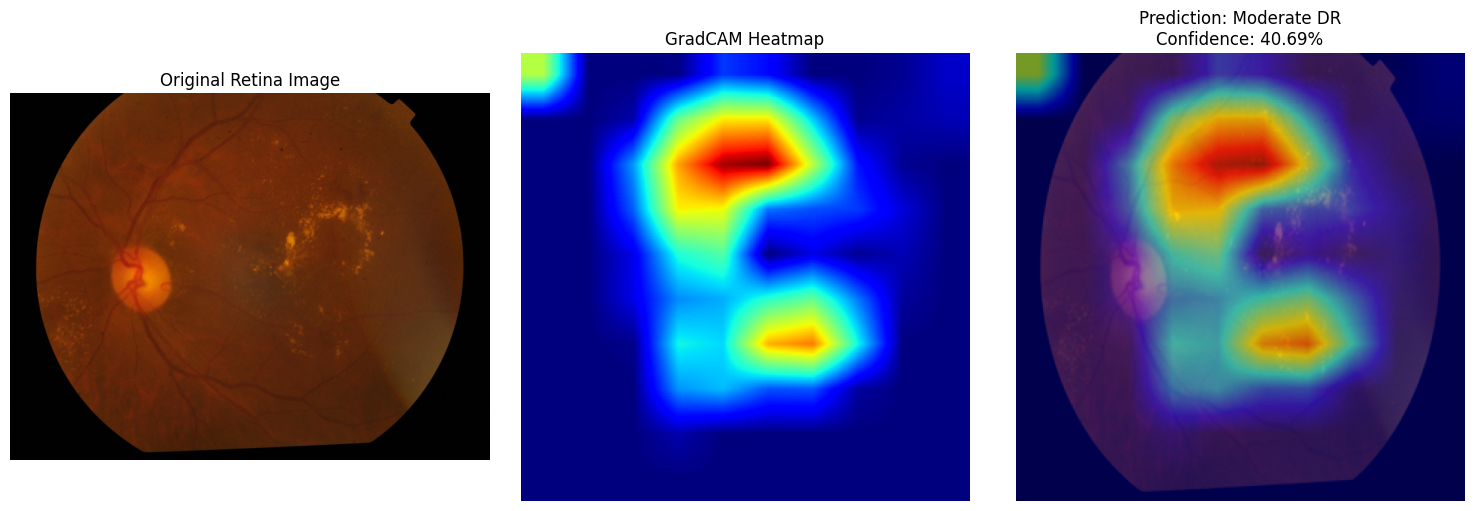


Heatmap saved successfully!


In [27]:
# # ============================================
# # OVERLAY HEATMAP ON IMAGE
# # ============================================

# rgb_image = np.array(
#     image.resize((224, 224))
# ).astype(np.float32) / 255.0

# visualization = show_cam_on_image(

#     rgb_image,

#     grayscale_cam,

#     use_rgb=True
# )

# plt.figure(figsize=(8, 8))

# plt.imshow(visualization)

# plt.title("GradCAM Heatmap")

# plt.axis("off")

# plt.show()

# ============================================
# PROFESSIONAL HEATMAP VISUALIZATION
# ============================================

import matplotlib.pyplot as plt

# ============================================
# CREATE FIGURE
# ============================================

plt.figure(figsize=(15, 5))

# ============================================
# ORIGINAL IMAGE
# ============================================

plt.subplot(1, 3, 1)

plt.imshow(original_image)

plt.title("Original Retina Image")

plt.axis("off")

# ============================================
# GRADCAM HEATMAP
# ============================================

plt.subplot(1, 3, 2)

plt.imshow(grayscale_cam, cmap='jet')

plt.title("GradCAM Heatmap")

plt.axis("off")

# ============================================
# OVERLAY IMAGE
# ============================================

plt.subplot(1, 3, 3)

plt.imshow(visualization)

plt.title(
    f"Prediction: {predicted_label}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")

# ============================================
# SAVE OUTPUT
# ============================================

plt.tight_layout()

plt.savefig(
    "../outputs/heatmaps/gradcam_result.png",
    bbox_inches='tight'
)

plt.show()

print("\nHeatmap saved successfully!")


Image 1
True Label: Proliferative DR
Predicted: Proliferative DR
Confidence: 74.10%
✓ Acceptable Confidence

Image 2
True Label: Proliferative DR
Predicted: Proliferative DR
Confidence: 92.07%
✓ Acceptable Confidence

Image 3
True Label: No DR
Predicted: No DR
Confidence: 98.66%
✓ Acceptable Confidence

Image 4
True Label: Mild DR
Predicted: Moderate DR
Confidence: 44.73%
⚠ Low Confidence Prediction

Image 5
True Label: No DR
Predicted: No DR
Confidence: 99.57%
✓ Acceptable Confidence


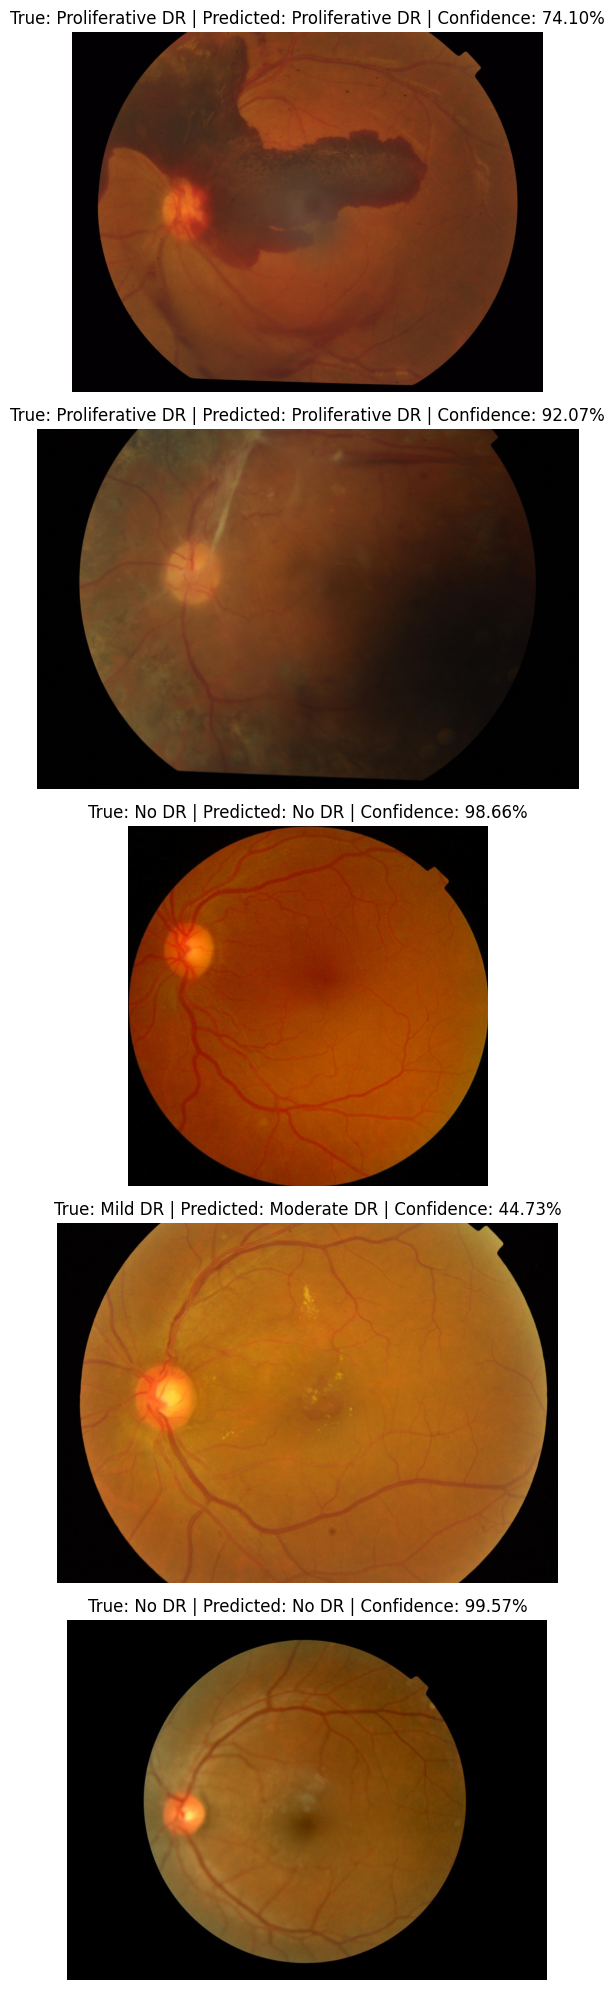

In [28]:
# ============================================
# TEST MULTIPLE RANDOM RETINAL IMAGES
# ============================================

import random
import os
import matplotlib.pyplot as plt

# ============================================
# CLASS NAMES
# ============================================

class_names = {
    0: "No DR",
    1: "Mild DR",
    2: "Moderate DR",
    3: "Severe DR",
    4: "Proliferative DR"
}

# ============================================
# TEST DIRECTORY
# ============================================

test_dir = "../dataset/test"

# ============================================
# SELECT 5 RANDOM IMAGES
# ============================================

random_images = []

for _ in range(5):

    selected_class = random.choice([
        "0", "1", "2", "3", "4"
    ])

    image_name = random.choice(
        os.listdir(
            os.path.join(test_dir, selected_class)
        )
    )

    image_path = os.path.join(
        test_dir,
        selected_class,
        image_name
    )

    random_images.append(
        (selected_class, image_path)
    )

# ============================================
# PREDICTION LOOP
# ============================================

plt.figure(figsize=(20, 20))

for idx, (true_class, image_path) in enumerate(random_images):

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Transform image
    input_tensor = transform(image)
    input_tensor = input_tensor.unsqueeze(0).to(device)

    # Model prediction
    with torch.no_grad():

        outputs = model(input_tensor)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidence, predicted = torch.max(
            probabilities,
            1
        )

    predicted_class = predicted.item()

    confidence_score = confidence.item() * 100

    # ============================================
    # DISPLAY IMAGE
    # ============================================

    plt.subplot(5, 1, idx + 1)

    plt.imshow(image)

    plt.title(

        f"True: {class_names[int(true_class)]} | "
        f"Predicted: {class_names[predicted_class]} | "
        f"Confidence: {confidence_score:.2f}%"
    )

    plt.axis("off")

    # ============================================
    # PRINT RESULTS
    # ============================================

    print("\n===================================")

    print(f"Image {idx+1}")

    print(f"True Label: {class_names[int(true_class)]}")

    print(
        f"Predicted: "
        f"{class_names[predicted_class]}"
    )

    print(
        f"Confidence: "
        f"{confidence_score:.2f}%"
    )

    if confidence_score < 65:

        print(
            "⚠ Low Confidence Prediction"
        )

    else:

        print(
            "✓ Acceptable Confidence"
        )

plt.tight_layout()

plt.show()